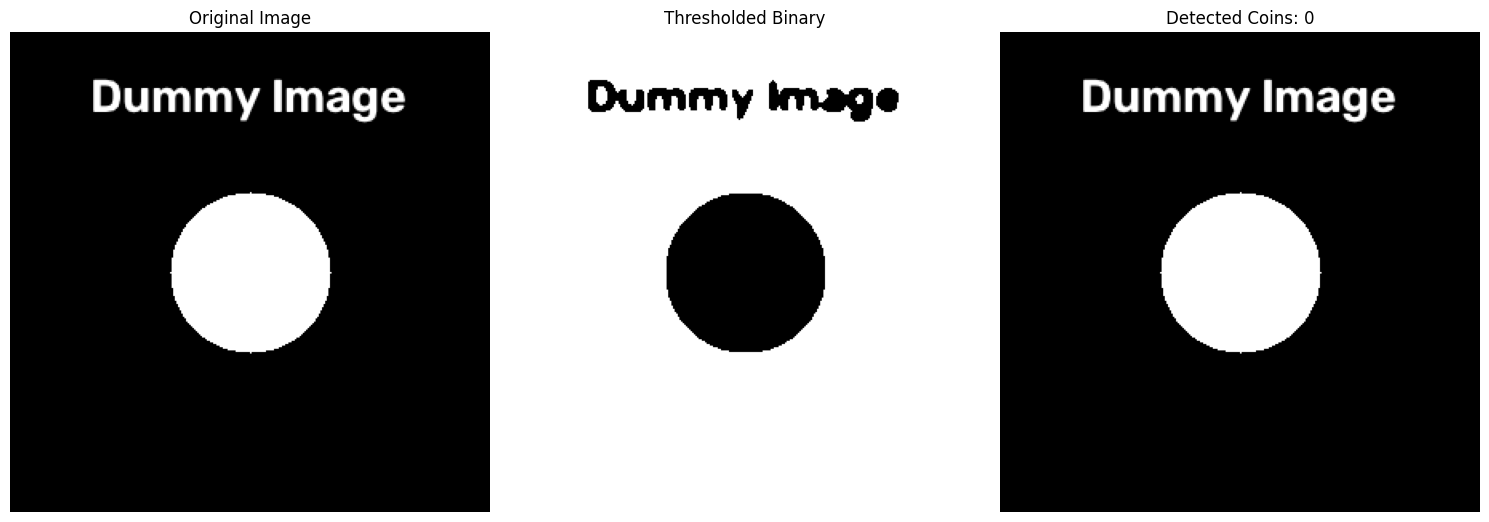

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Read and convert image
image_path = "/content/sample_data/Screenshot 2025-09-10 102635.jpg" # replace with your coin image
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Check if image was loaded successfully, if not, create a dummy image
if img is None:
    print(f"Warning: Image not found at {image_path}. Creating a dummy image for demonstration.")
    # Create a 300x300 black image with a white circle in the middle as a placeholder
    img = np.zeros((300, 300), dtype=np.uint8)
    cv2.circle(img, (150, 150), 50, 255, -1) # Draw a white circle
    cv2.putText(img, "Dummy Image", (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, 255, 2)

# 2. Smooth to reduce noise
blur = cv2.GaussianBlur(img, (11, 11), 0)

# 3. Threshold to binary (Otsu automatically selects threshold)
_, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# 4. Morphological closing to fill small gaps inside coins
kernel = np.ones((3, 3), np.uint8)
closing = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=4)

# 5. Erosion with disk kernel to separate touching coins
kernel_disk = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
eroded = cv2.erode(closing, kernel_disk, iterations=2)

# 6. Find contours (connected components)
contours, _ = cv2.findContours(eroded, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# 7. Count and mark coins
count = 0
# Ensure result_img is BGR if original img was grayscale and we need to draw colored rectangles
result_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
for cnt in contours:
    area = cv2.contourArea(cnt)
    if 1000 < area < 30000: # filter small noise and huge blobs
        count += 1
        x, y, w, h = cv2.boundingRect(cnt)
        cv2.rectangle(result_img, (x, y), (x+w, y+h), (0, 255, 0), 2)

# 8. Display results
plt.figure(figsize=(15, 8))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(thresh, cmap='gray')
plt.title("Thresholded Binary")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(result_img)
plt.title(f"Detected Coins: {count}")
plt.axis("off")

plt.tight_layout()
plt.show()